In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the SMS spam dataset

df = pd.read_csv("spam.csv", encoding="latin-1")

# Display the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Keep only the required columns

df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Check the cleaned dataset
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape: (5572, 2)

Columns: ['label', 'message']

Missing Values:
label      0
message    0
dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Message Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


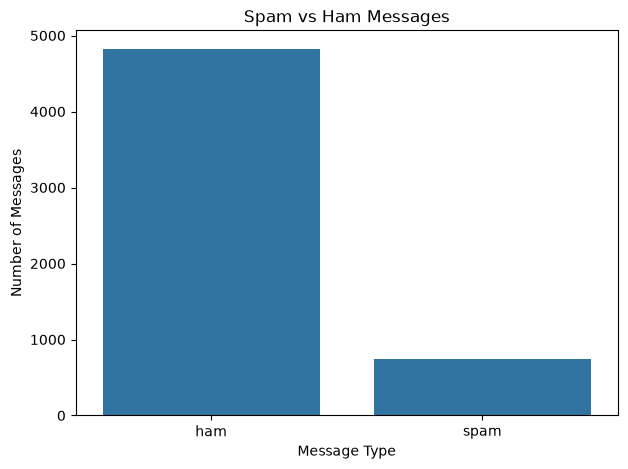

In [4]:
# Check the distribution of spam and ham messages

print("Message Distribution:")
print(df['label'].value_counts())

# Visualize the distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='label'
)

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [5]:
# Convert labels into numerical values

df['label_encoded'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

print(df[['label', 'label_encoded']].head())

print("\nLabel Distribution:")
print(df['label_encoded'].value_counts())

  label  label_encoded
0   ham              0
1   ham              0
2  spam              1
3   ham              0
4   ham              0

Label Distribution:
label_encoded
0    4825
1     747
Name: count, dtype: int64


In [6]:
# Convert text messages into TF-IDF features

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english'
)

X = tfidf.fit_transform(df['message'])
y = df['label_encoded']

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5572, 8404)


In [7]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [8]:
# Train Logistic Regression model

spam_model = LogisticRegression(max_iter=1000)

spam_model.fit(X_train, y_train)

# Make predictions
y_pred = spam_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
# Evaluate the spam detection model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

Accuracy: 0.9542600896860987
Accuracy Percentage: 95.42600896860986 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       966
        Spam       1.00      0.66      0.79       149

    accuracy                           0.95      1115
   macro avg       0.97      0.83      0.88      1115
weighted avg       0.96      0.95      0.95      1115



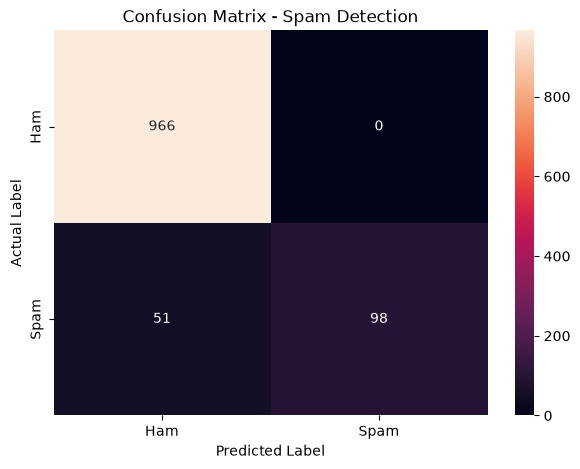

In [10]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix - Spam Detection')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [11]:
# Test the model with new messages

new_messages = [
    "Congratulations! You have won a free prize. Claim your reward now!",
    "Hey, are we meeting for class tomorrow?",
    "URGENT! You have been selected for a special offer. Click now!",
    "Can you send me the assignment notes?"
]

# Convert new messages into TF-IDF features
new_messages_tfidf = tfidf.transform(new_messages)

# Predict
predictions = spam_model.predict(new_messages_tfidf)

# Display results
for message, prediction in zip(new_messages, predictions):
    result = "Spam" if prediction == 1 else "Ham"
    print(f"Message: {message}")
    print(f"Prediction: {result}")
    print("-" * 60)

Message: Congratulations! You have won a free prize. Claim your reward now!
Prediction: Spam
------------------------------------------------------------
Message: Hey, are we meeting for class tomorrow?
Prediction: Ham
------------------------------------------------------------
Message: URGENT! You have been selected for a special offer. Click now!
Prediction: Ham
------------------------------------------------------------
Message: Can you send me the assignment notes?
Prediction: Ham
------------------------------------------------------------


## Conclusion

The Email Spam Detection project was successfully completed using
Natural Language Processing and Logistic Regression.

- The SMS dataset was cleaned and prepared for analysis.
- Messages were converted into numerical features using TF-IDF.
- The dataset was divided into training and testing sets.
- A Logistic Regression model was trained to classify messages.
- The model was evaluated using accuracy, precision, recall, and F1-score.
- A confusion matrix was created to visualize the classification results.
- The trained model was also tested on new messages.
- The model successfully classified messages as Ham or Spam.

Overall, this project demonstrated a complete machine learning workflow
for text classification and spam detection.